
=== XOR Gate using Multi-Layer Perceptron ===
Hidden Layer Weights:
 [[-2.02203499  3.00647731  3.81637124 -0.53547191 -3.4247781  -2.12137252]
 [-2.5058281   3.50195986 -2.83418785  3.6600115  -2.66601213  3.47410348]
 [ 3.55916764 -3.77699125 -2.83124594 -0.98651079  1.53882372 -2.49361811]]
Output Layer Weights:
 [[-2.19602205]
 [ 4.23336363]
 [-4.92578751]
 [-2.13022726]
 [ 1.61287018]
 [-3.57421906]]
Biases:
 [array([ 0.25628767, -1.13875126,  0.96471408, -1.00334494, -0.25306276,
        0.64297205]), array([0.85215463])]

Predictions: [0 1 1 0 1 0 0 1]

Accuracy: 1.0

Confusion Matrix:
 [[4 0]
 [0 4]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         4

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



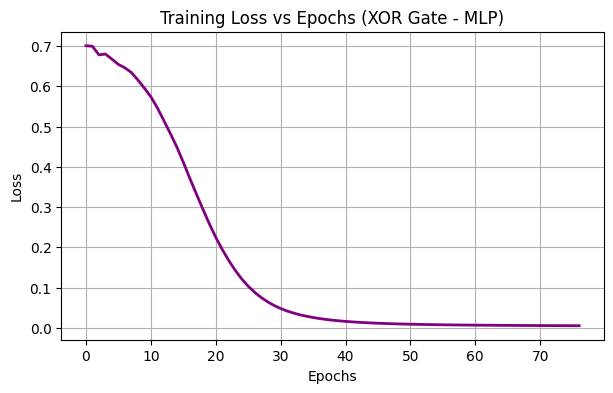

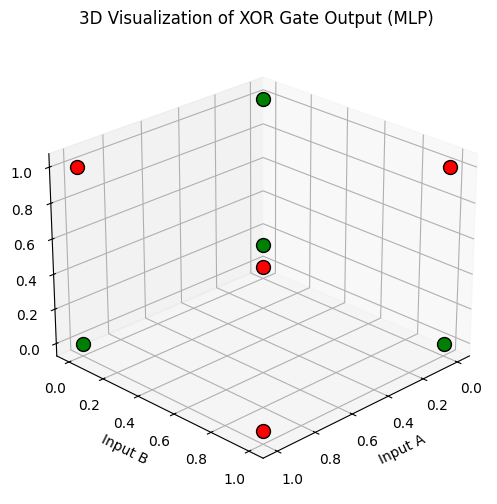

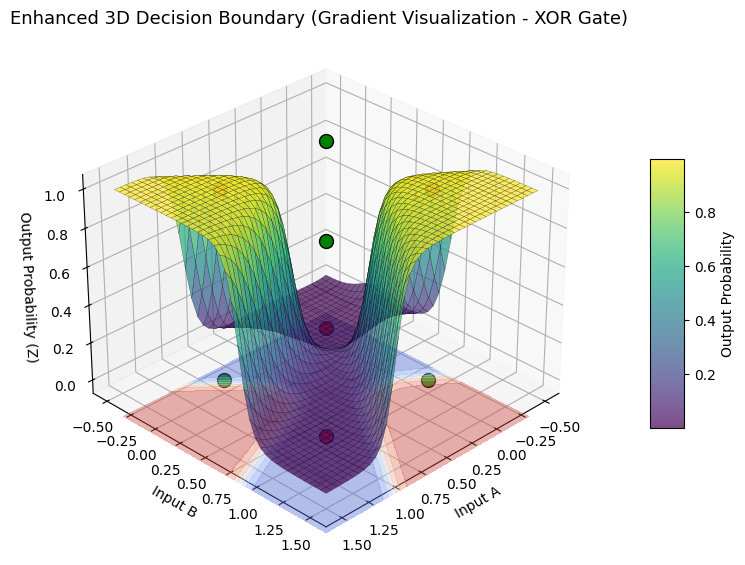

In [1]:
# xor_gate_mlp.py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from mpl_toolkits.mplot3d import Axes3D

# ----------------------------
# 1. Define the dataset (XOR gate for 3 variables)
# ----------------------------
# Inputs (A, B, C)
X = np.array([[0, 0, 0],
              [0, 0, 1],
              [0, 1, 0],
              [0, 1, 1],
              [1, 0, 0],
              [1, 0, 1],
              [1, 1, 0],
              [1, 1, 1]])

# Output (A XOR B XOR C)
y = np.array([0, 1, 1, 0, 1, 0, 0, 1])

# ----------------------------
# 2. Create and train the MLP model
# ----------------------------
model = MLPClassifier(hidden_layer_sizes=(6,), activation='tanh', solver='adam',
                      learning_rate_init=0.1, max_iter=1000, random_state=42)

# Train model
model.fit(X, y)

# Loss curve (training loss per iteration)
loss_curve = model.loss_curve_

# ----------------------------
# 3. Predictions and metrics
# ----------------------------
y_pred = model.predict(X)
acc = accuracy_score(y, y_pred)
cm = confusion_matrix(y, y_pred)
report = classification_report(y, y_pred)

# ----------------------------
# 4. Display results
# ----------------------------
print("\n=== XOR Gate using Multi-Layer Perceptron ===")
print("Hidden Layer Weights:\n", model.coefs_[0])
print("Output Layer Weights:\n", model.coefs_[1])
print("Biases:\n", model.intercepts_)
print("\nPredictions:", y_pred)
print("\nAccuracy:", acc)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", report)

# ----------------------------
# 5. Plot Loss Curve (Error vs Iterations)
# ----------------------------
plt.figure(figsize=(7, 4))
plt.plot(loss_curve, color='purple', linewidth=2)
plt.title("Training Loss vs Epochs (XOR Gate - MLP)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# ----------------------------
# 6. 3D Visualization of Predictions
# ----------------------------
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

for xi, yi in zip(X, y_pred):
    color = 'green' if yi == 1 else 'red'
    ax.scatter(xi[0], xi[1], xi[2], c=color, s=100, edgecolor='k')

ax.set_title("3D Visualization of XOR Gate Output (MLP)")
ax.set_xlabel("Input A")
ax.set_ylabel("Input B")
ax.set_zlabel("Input C")
ax.view_init(25, 45)
plt.show()

# ----------------------------
# 7. Enhanced 3D Decision Boundary Visualization
# ----------------------------
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot the points again with class colors
for xi, yi in zip(X, y_pred):
    color = 'green' if yi == 1 else 'red'
    ax.scatter(xi[0], xi[1], xi[2], c=color, s=100, edgecolor='k', depthshade=True)

# Create mesh grid
x_range = np.linspace(-0.5, 1.5, 40)
y_range = np.linspace(-0.5, 1.5, 40)
xx, yy = np.meshgrid(x_range, y_range)

# To visualize decision surface, fix one variable (C)
zz = np.zeros_like(xx)

# Predict model output probabilities for visualization
input_grid = np.c_[xx.ravel(), yy.ravel(), zz.ravel()]
Z = model.predict_proba(input_grid)[:, 1]  # Probability for class 1
Z = Z.reshape(xx.shape)

# Plot decision surface with gradient shading
surf = ax.plot_surface(xx, yy, Z, cmap='viridis', alpha=0.7, edgecolor='k', linewidth=0.2)
fig.colorbar(surf, shrink=0.5, aspect=8, pad=0.1, label='Output Probability')

# Optional contour projection for clarity
ax.contourf(xx, yy, Z, zdir='z', offset=-0.2, cmap='coolwarm', alpha=0.4)

ax.set_title("Enhanced 3D Decision Boundary (Gradient Visualization - XOR Gate)", fontsize=13)
ax.set_xlabel("Input A")
ax.set_ylabel("Input B")
ax.set_zlabel("Output Probability (Z)")
ax.view_init(30, 45)
plt.show()

In [2]:
import joblib
joblib.dump(model, "xor_gate_mlp.pkl")

['xor_gate_mlp.pkl']